# Codificação de Sinais Multimedia

## Trabalho Laboratorial 4

- 52146 - Margarida Andrade
- 52345 - Jorge Gonçalves
- 52708 - Helena Nina

In [ ]:
import json
from pathlib import Path
import struct

import cv2
import matplotlib.pyplot as plt
import numpy as np

## Exercício 1
### Alínea a

Imagem usada: bola_1.tiff | shape=(240, 352)
Erro maximo apos DCT+IDCT (sem quantizacao): 1


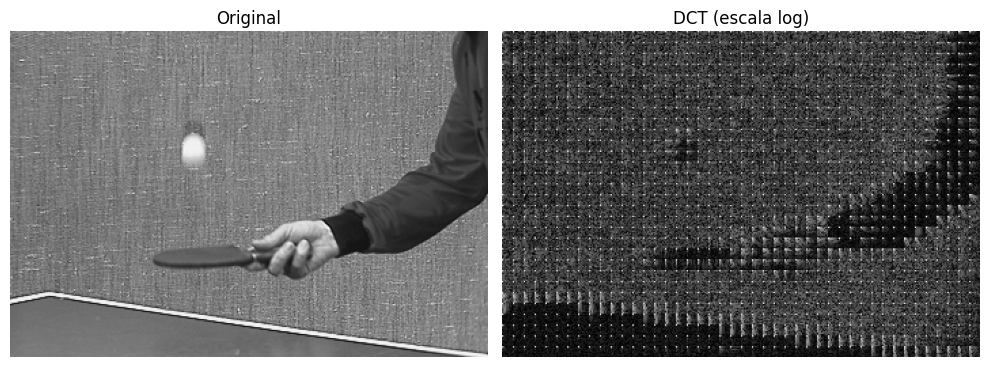

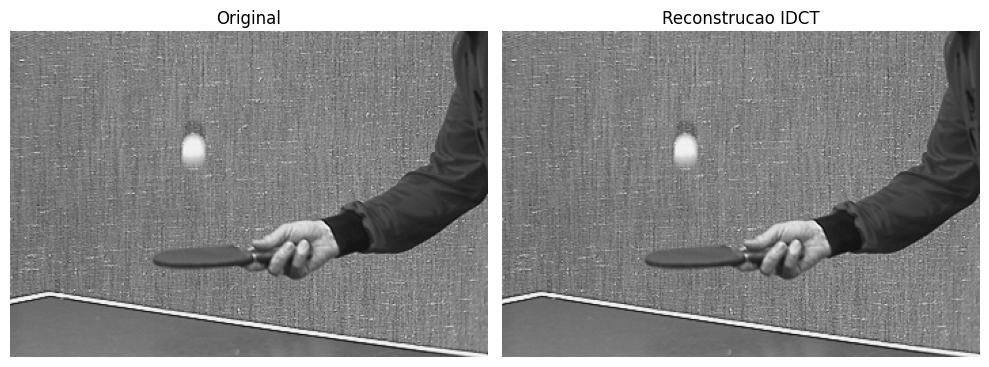

In [8]:
# ------------------------------
# Utilitários gerais do codificador JPEG sequencial (tons de cinzento)
# ------------------------------


def locate_tp4_dir():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for base in candidates:
        p = base / "Tabelas_jpeg.json"
        if p.exists():
            return base

    for p in Path.cwd().rglob("Tabelas_jpeg.json"):
        return p.parent

    raise FileNotFoundError("Nao foi possivel localizar a pasta tp4 com Tabelas_jpeg.json")


TP4_DIR = locate_tp4_dir()
IMG_PATH = TP4_DIR / "bola_seq" / "bola_1.tiff"
TABLES_PATH = TP4_DIR / "Tabelas_jpeg.json"


def load_tables_from_json(json_path: Path):
    """Carrega Q, K3, K5 e quality_factor a partir do ficheiro fornecido em tp4."""
    data = json.loads(json_path.read_text(encoding="utf-8"))

    code_src = None
    for cell in data.get("cells", []):
        if cell.get("cell_type") == "code":
            src = "".join(cell.get("source", []))
            if "Q = np.zeros((8, 8))" in src and "K3 = dict()" in src and "K5 = dict()" in src:
                code_src = src
                break

    if code_src is None:
        raise RuntimeError("Nao foi possivel encontrar as tabelas no ficheiro Tabelas_jpeg.json")

    start = code_src.find("Q = np.zeros((8, 8))")
    end = code_src.find("return factor")
    if start < 0 or end < 0:
        raise RuntimeError("Estrutura inesperada em Tabelas_jpeg.json")

    snippet = code_src[start : end + len("return factor")]
    namespace = {"np": np}
    exec(snippet, namespace)

    Q = namespace["Q"].astype(np.float32)
    K3 = namespace["K3"]
    K5 = namespace["K5"]
    quality_factor_fn = namespace["quality_factor"]
    ind_zz = namespace["ind_zz"].astype(np.int32)
    return Q, K3, K5, ind_zz, quality_factor_fn


Q, K3, K5, IND_ZZ, quality_factor = load_tables_from_json(TABLES_PATH)


def read_gray_image(path: Path):
    # imdecode + fromfile evita problemas do cv2.imread com caminhos Unicode no Windows
    data = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Imagem nao encontrada: {path}")
    return img


def pad_to_block_size(img, block=8):
    h, w = img.shape
    hp = ((h + block - 1) // block) * block
    wp = ((w + block - 1) // block) * block
    out = np.zeros((hp, wp), dtype=np.float32)
    out[:h, :w] = img.astype(np.float32)
    return out, h, w


def crop_original(img, h, w):
    return img[:h, :w]


def block_iter(img, block=8):
    h, w = img.shape
    for i in range(0, h, block):
        for j in range(0, w, block):
            yield i, j, img[i : i + block, j : j + block]


def dct2_blocks(img):
    padded, h, w = pad_to_block_size(img)
    shifted = padded - 128.0
    out = np.zeros_like(shifted, dtype=np.float32)
    for i, j, block in block_iter(shifted):
        out[i : i + 8, j : j + 8] = cv2.dct(block.astype(np.float32))
    return out, h, w


def idct2_blocks(coeff, h, w):
    out = np.zeros_like(coeff, dtype=np.float32)
    for i, j, block in block_iter(coeff):
        out[i : i + 8, j : j + 8] = cv2.idct(block.astype(np.float32))
    out = np.clip(out + 128.0, 0, 255)
    return crop_original(out, h, w).astype(np.uint8)


def show_images_side_by_side(img1, img2, title1, title2, cmap="gray"):
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap=cmap)
    plt.title(title1)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap=cmap)
    plt.title(title2)
    plt.axis("off")
    plt.tight_layout()


def coeff_to_display(coeff):
    # visualização log para evidenciar baixas/altas frequências
    return np.log1p(np.abs(coeff))


def snr_db(original, reconstructed):
    x = original.astype(np.float64)
    y = reconstructed.astype(np.float64)
    signal = np.sum(x ** 2)
    noise = np.sum((x - y) ** 2)
    if noise == 0:
        return np.inf
    return 10 * np.log10(signal / noise)


img0 = read_gray_image(IMG_PATH)
coeff0, h0, w0 = dct2_blocks(img0)
img0_rec = idct2_blocks(coeff0, h0, w0)

print(f"Imagem usada: {IMG_PATH.name} | shape={img0.shape}")
print(f"Erro maximo apos DCT+IDCT (sem quantizacao): {np.max(np.abs(img0.astype(int) - img0_rec.astype(int)))}")

show_images_side_by_side(img0, coeff_to_display(coeff0), "Original", "DCT (escala log)")
show_images_side_by_side(img0, img0_rec, "Original", "Reconstrucao IDCT")

### Alínea b

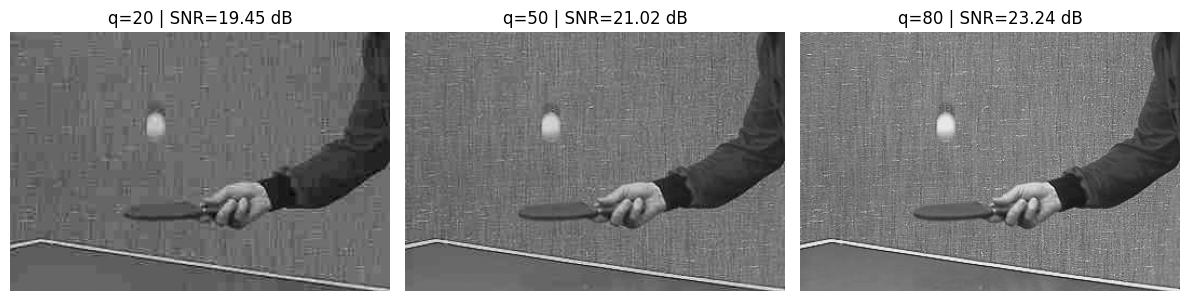

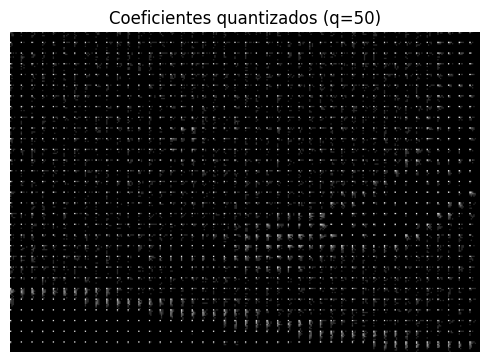

In [9]:
def quantize_blocks(coeff, q):
    factor = quality_factor(q)
    qmat = Q * factor
    out = np.zeros_like(coeff, dtype=np.int16)
    for i, j, block in block_iter(coeff):
        out[i : i + 8, j : j + 8] = np.round(block / qmat).astype(np.int16)
    return out, qmat


def dequantize_blocks(qcoeff, qmat):
    out = np.zeros_like(qcoeff, dtype=np.float32)
    for i, j, block in block_iter(qcoeff):
        out[i : i + 8, j : j + 8] = block.astype(np.float32) * qmat
    return out


img = read_gray_image(IMG_PATH)
coeff, h, w = dct2_blocks(img)

qualities = [20, 50, 80]
plt.figure(figsize=(12, 4))
for idx, q in enumerate(qualities, start=1):
    qcoeff, qmat = quantize_blocks(coeff, q)
    coeff_rec = dequantize_blocks(qcoeff, qmat)
    rec = idct2_blocks(coeff_rec, h, w)
    snr = snr_db(img, rec)

    plt.subplot(1, len(qualities), idx)
    plt.imshow(rec, cmap="gray")
    plt.title(f"q={q} | SNR={snr:.2f} dB")
    plt.axis("off")

plt.tight_layout()

q_demo = 50
qcoeff_demo, _ = quantize_blocks(coeff, q_demo)
plt.figure(figsize=(5, 4))
plt.imshow(coeff_to_display(qcoeff_demo), cmap="gray")
plt.title(f"Coeficientes quantizados (q={q_demo})")
plt.axis("off")
plt.tight_layout()

### Alínea c

In [10]:
def blocks_to_dc_list(qcoeff):
    dcs = []
    for _, _, block in block_iter(qcoeff):
        dcs.append(int(block[0, 0]))
    return dcs


def dc_differential_encode(dc_values):
    out = []
    prev = 0
    for dc in dc_values:
        out.append(dc - prev)
        prev = dc
    return out


def dc_differential_decode(dc_diff):
    out = []
    acc = 0
    for d in dc_diff:
        acc += d
        out.append(acc)
    return out


img = read_gray_image(IMG_PATH)
coeff, _, _ = dct2_blocks(img)
qcoeff, _ = quantize_blocks(coeff, q=50)

orig_dc = blocks_to_dc_list(qcoeff)
dc_diff = dc_differential_encode(orig_dc)
dc_rec = dc_differential_decode(dc_diff)

print("Primeiros 10 DC originais:", orig_dc[:10])
print("Primeiros 10 DC diferenciais:", dc_diff[:10])
print("DC recuperado igual ao original?", np.array_equal(np.array(orig_dc), np.array(dc_rec)))

Primeiros 10 DC originais: [-31, -31, -31, -31, -31, -30, -30, -30, -29, -30]
Primeiros 10 DC diferenciais: [-31, 0, 0, 0, 0, 1, 0, 0, 1, -1]
DC recuperado igual ao original? True


### Alínea d

In [11]:
def zigzag_flatten(block):
    flat_f = block.reshape((64,), order="F")
    return flat_f[IND_ZZ]


def zigzag_unflatten(zz):
    inv = np.zeros(64, dtype=np.int16)
    inv[IND_ZZ] = zz
    return inv.reshape((8, 8), order="F")


def ac_rle_encode_from_block(block):
    zz = zigzag_flatten(block)
    ac = zz[1:]
    pairs = []
    run = 0
    for v in ac:
        v = int(v)
        if v == 0:
            run += 1
        else:
            while run >= 16:
                pairs.append((15, 0))
                run -= 16
            pairs.append((run, v))
            run = 0
    pairs.append((0, 0))
    return pairs


def ac_rle_decode_to_block(dc_value, pairs):
    out = [int(dc_value)]
    for run, val in pairs:
        if (run, val) == (0, 0):
            break
        if (run, val) == (15, 0):
            out.extend([0] * 16)
            continue
        out.extend([0] * run)
        out.append(int(val))

    if len(out) < 64:
        out.extend([0] * (64 - len(out)))
    out = np.array(out[:64], dtype=np.int16)
    return zigzag_unflatten(out)


img = read_gray_image(IMG_PATH)
coeff, _, _ = dct2_blocks(img)
qcoeff, _ = quantize_blocks(coeff, q=50)
first_block = next(block_iter(qcoeff))[2]
pairs = ac_rle_encode_from_block(first_block)
first_block_rec = ac_rle_decode_to_block(first_block[0, 0], pairs)

print("Exemplo pares (run, valor) do 1.o bloco:", pairs[:12])
print("Bloco reconstruido igual?", np.array_equal(first_block, first_block_rec))

Exemplo pares (run, valor) do 1.o bloco: [(0, -1), (0, 1), (1, 1), (0, 1), (2, -1), (2, -1), (0, -1), (5, -1), (0, 0)]
Bloco reconstruido igual? True


### Alínea e

Reconstrucao de arrays (c+d) correta? True
SNR final da pipeline (ate e), q=50: 21.02 dB


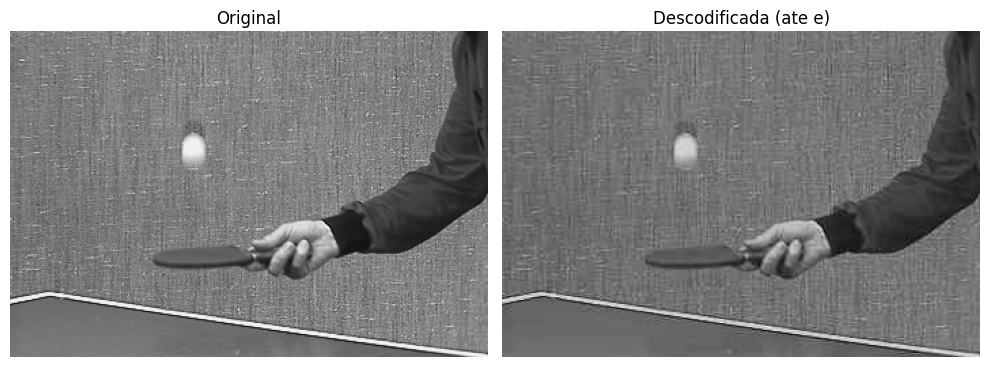

In [12]:
def encode_arrays_from_qcoeff(qcoeff):
    dc_values = []
    ac_pairs_per_block = []
    for _, _, block in block_iter(qcoeff):
        dc_values.append(int(block[0, 0]))
        ac_pairs_per_block.append(ac_rle_encode_from_block(block))
    dc_diff = dc_differential_encode(dc_values)
    return dc_diff, ac_pairs_per_block


def decode_qcoeff_from_arrays(dc_diff, ac_pairs_per_block, shape):
    hp, wp = shape
    qcoeff = np.zeros((hp, wp), dtype=np.int16)
    dc_values = dc_differential_decode(dc_diff)

    block_idx = 0
    for i in range(0, hp, 8):
        for j in range(0, wp, 8):
            block = ac_rle_decode_to_block(dc_values[block_idx], ac_pairs_per_block[block_idx])
            qcoeff[i : i + 8, j : j + 8] = block
            block_idx += 1
    return qcoeff


img = read_gray_image(IMG_PATH)
coeff, h, w = dct2_blocks(img)
qcoeff, qmat = quantize_blocks(coeff, q=50)

dc_diff_arr, ac_pairs_arr = encode_arrays_from_qcoeff(qcoeff)
qcoeff_rec = decode_qcoeff_from_arrays(dc_diff_arr, ac_pairs_arr, qcoeff.shape)

coeff_rec = dequantize_blocks(qcoeff_rec, qmat)
img_rec = idct2_blocks(coeff_rec, h, w)

print("Reconstrucao de arrays (c+d) correta?", np.array_equal(qcoeff, qcoeff_rec))
print(f"SNR final da pipeline (ate e), q=50: {snr_db(img, img_rec):.2f} dB")
show_images_side_by_side(img, img_rec, "Original", "Descodificada (ate e)")

### Alínea f

In [13]:
def magnitude_category(v):
    v = int(v)
    if v == 0:
        return 0
    return int(np.floor(np.log2(abs(v))) + 1)


def value_to_bits(v, size):
    if size == 0:
        return ""
    if v >= 0:
        return format(v, f"0{size}b")
    return format((1 << size) - 1 + v, f"0{size}b")


def bits_to_value(bits, size):
    if size == 0:
        return 0
    x = int(bits, 2)
    if x >= (1 << (size - 1)):
        return x
    return x - ((1 << size) - 1)


def huffman_encode_arrays(dc_diff, ac_pairs_per_block):
    bitstream = []

    for d in dc_diff:
        cat = magnitude_category(d)
        if cat not in K3:
            raise ValueError(f"Categoria DC nao suportada pela tabela K3: {cat}")
        bitstream.append(K3[cat])
        bitstream.append(value_to_bits(d, cat))

    for pairs in ac_pairs_per_block:
        for run, val in pairs:
            if (run, val) == (0, 0):
                bitstream.append(K5[(0, 0)])
                continue
            if (run, val) == (15, 0):
                bitstream.append(K5[(15, 0)])
                continue
            size = magnitude_category(val)
            key = (run, size)
            if key not in K5:
                raise ValueError(f"Par AC nao suportado por K5: {key}")
            bitstream.append(K5[key])
            bitstream.append(value_to_bits(val, size))

    return "".join(bitstream)


def bits_to_bytes(bitstring):
    pad = (8 - (len(bitstring) % 8)) % 8
    bitstring_padded = bitstring + ("0" * pad)
    arr = bytearray()
    for i in range(0, len(bitstring_padded), 8):
        arr.append(int(bitstring_padded[i : i + 8], 2))
    return bytes(arr), pad


def bytes_to_bits(data):
    return "".join(format(b, "08b") for b in data)


def write_bitstream_file(path, bitstring, h, w, hp, wp, q):
    payload, pad = bits_to_bytes(bitstring)
    with open(path, "wb") as f:
        f.write(b"JPGS")
        f.write(struct.pack(">HHHHBI", h, w, hp, wp, int(q), len(bitstring)))
        f.write(payload)
        f.write(struct.pack("B", pad))


def huffman_decode_arrays(bitstring, n_blocks):
    inv_k3 = {v: k for k, v in K3.items()}
    inv_k5 = {v: k for k, v in K5.items()}

    def read_huff_code(s, idx, inv_table):
        cur = ""
        while idx < len(s):
            cur += s[idx]
            idx += 1
            if cur in inv_table:
                return inv_table[cur], idx
        raise ValueError("Fim inesperado do bitstream ao ler Huffman")

    idx = 0
    dc_diff = []
    for _ in range(n_blocks):
        cat, idx = read_huff_code(bitstring, idx, inv_k3)
        amp = bitstring[idx : idx + cat]
        idx += cat
        dc_diff.append(bits_to_value(amp, cat))

    ac_pairs_per_block = []
    for _ in range(n_blocks):
        pairs = []
        while True:
            symbol, idx = read_huff_code(bitstring, idx, inv_k5)
            run, size = symbol
            if (run, size) == (0, 0):
                pairs.append((0, 0))
                break
            if (run, size) == (15, 0):
                pairs.append((15, 0))
                continue
            amp = bitstring[idx : idx + size]
            idx += size
            pairs.append((run, bits_to_value(amp, size)))
        ac_pairs_per_block.append(pairs)

    return dc_diff, ac_pairs_per_block


def read_bitstream_file(path):
    with open(path, "rb") as f:
        magic = f.read(4)
        if magic != b"JPGS":
            raise ValueError("Ficheiro invalido: magic nao reconhecida")

        h, w, hp, wp, q, n_bits = struct.unpack(">HHHHBI", f.read(2 + 2 + 2 + 2 + 1 + 4)
        )
        data = f.read()
        pad = data[-1]
        payload = data[:-1]

    bits = bytes_to_bits(payload)[:n_bits]
    return bits, h, w, hp, wp, q


img = read_gray_image(IMG_PATH)
coeff, h, w = dct2_blocks(img)
q = 50
qcoeff, _ = quantize_blocks(coeff, q=q)
dc_diff_arr, ac_pairs_arr = encode_arrays_from_qcoeff(qcoeff)

bitstring = huffman_encode_arrays(dc_diff_arr, ac_pairs_arr)
out_file = TP4_DIR / "jpeg_seq_bits.bin"
write_bitstream_file(out_file, bitstring, h, w, qcoeff.shape[0], qcoeff.shape[1], q)

print(f"Ficheiro gerado: {out_file.name}")
print(f"Bits codificados: {len(bitstring)}")
print(f"Tamanho em bytes: {out_file.stat().st_size}")

Ficheiro gerado: jpeg_seq_bits.bin
Bits codificados: 47570
Tamanho em bytes: 5965


### Alínea g

Primeiros 10 valores DC diferenciais lidos: [-31, 0, 0, 0, 0, 1, 0, 0, 1, -1]
Primeiros pares AC do 1.o bloco: [(0, -1), (0, 1), (1, 1), (0, 1), (2, -1), (2, -1), (0, -1), (5, -1), (0, 0)]
SNR apos leitura do ficheiro: 21.02 dB
Taxa de compressao aproximada: 14.21x


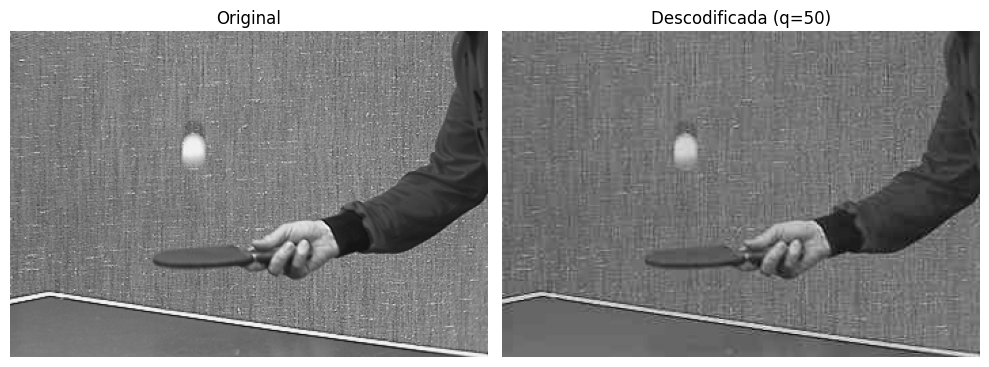

In [14]:
bits_in, h, w, hp, wp, q = read_bitstream_file(TP4_DIR / "jpeg_seq_bits.bin")
n_blocks = (hp // 8) * (wp // 8)

dc_diff_dec, ac_pairs_dec = huffman_decode_arrays(bits_in, n_blocks)

# arrays pedidos na alinea g
print("Primeiros 10 valores DC diferenciais lidos:", dc_diff_dec[:10])
print("Primeiros pares AC do 1.o bloco:", ac_pairs_dec[0][:12])

# reconstrucao completa da imagem a partir do ficheiro
img = read_gray_image(IMG_PATH)
coeff, _, _ = dct2_blocks(img)
_, qmat = quantize_blocks(coeff, q=q)

qcoeff_dec = decode_qcoeff_from_arrays(dc_diff_dec, ac_pairs_dec, (hp, wp))
coeff_dec = dequantize_blocks(qcoeff_dec, qmat)
img_dec = idct2_blocks(coeff_dec, h, w)

snr = snr_db(img, img_dec)
orig_bits = h * w * 8
comp_bits = len(bits_in)
cr = orig_bits / comp_bits if comp_bits > 0 else np.inf

print(f"SNR apos leitura do ficheiro: {snr:.2f} dB")
print(f"Taxa de compressao aproximada: {cr:.2f}x")

show_images_side_by_side(img, img_dec, "Original", f"Descodificada (q={q})")

## Exercício 2
### Alínea a

### Alínea b

### Alínea c

### Alínea d

### Alínea e

## Extra 


### Alínea a

### Alínea b

### Alínea c

#### i

#### ii

#### iii